# **Examen 2024 - Practico**
## Marcos Perez Martinez

---

* **Ejercicio 1**
>
> Primero cargamos el dataset. Luego decidimos que columnas son irrelevantes para saber el diagnostico del paciente. Estas columnas son tanto el ID del paciente como el MRI ID. La mano tampoco es relevante puesto que siempre tiene el mismo valor. Y eso seria meter ruido. 
> Luego miramos cuantos valores nulos hay y en que columnas para saber como manejarlos. Se hace esto porque es peligroso aplicar el fillna().median() a todo el data set, puede confundir valores numeros y textos. 
>

In [161]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

DATA_SET = "dementia_dataset.csv"

df = pd.read_csv(DATA_SET)
COLUMS_TO_DROP = ['Subject ID', 'MRI ID', 'Hand']

# Ejecutar solo una vez, luego no es necesario. 
#print("--- RECUENTO DE NULOS ---")
#print(df.isna().sum())
#print("-------------------------")

Una vez sabemos que columnas tienen valores nulos, los rellenamos y procedemos a quitar las columnas irrelevantes.

Luego codificamos el genero con un map {0, 1}. 
Y Group con LabelEncoder para darle valores numericos a los distintos grupos. 

In [162]:
df['SES'] = df['SES'].fillna(df['SES'].median())
df['MMSE'] = df['MMSE'].fillna(df['MMSE'].median())

df = df.drop(columns=COLUMS_TO_DROP)

In [163]:
df['M/F'] = df['M/F'].map({'M': 0, 'F': 1})

le = LabelEncoder()
df['Group'] = le.fit_transform(df['Group'])

A continuacion separamos X e y. Y escalamos X. 

In [164]:
X = df.drop(columns=['Group']).values
y = df['Group'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

---
* **Ejercicio 2**

Para la visualizacion de la limpieza, vamos a realizar lo siguiente: 
    * **Heatmap**: para ver la relacion matematica entre las variables. 
    * **PCA**: para ver todas las variables en 2d en relacion a 'Group'

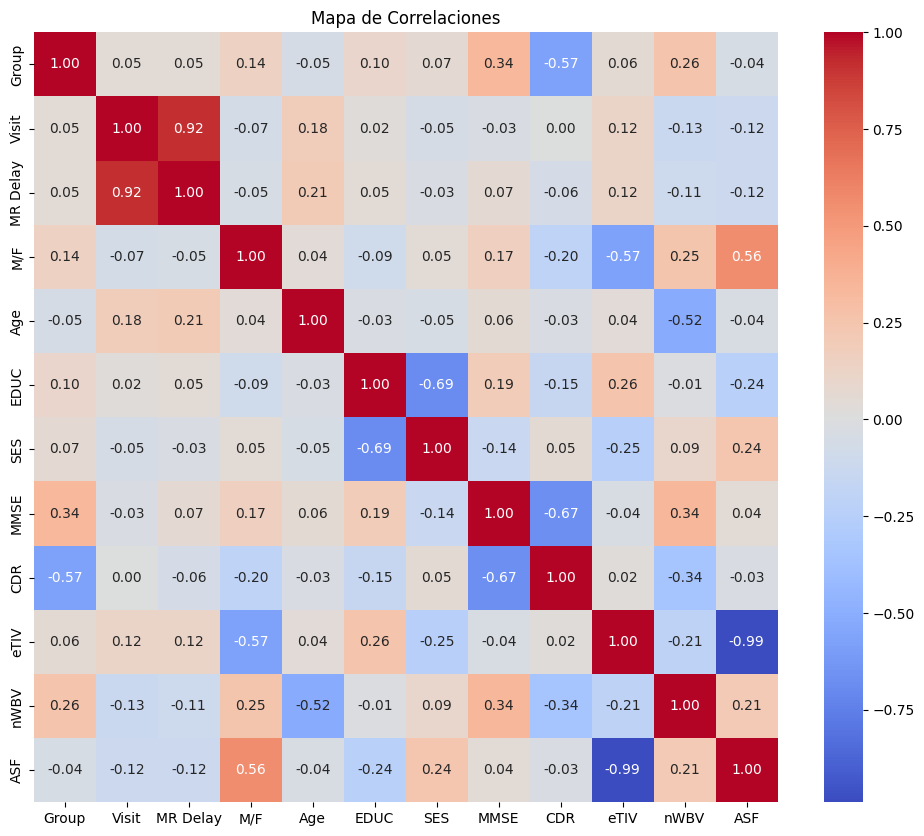

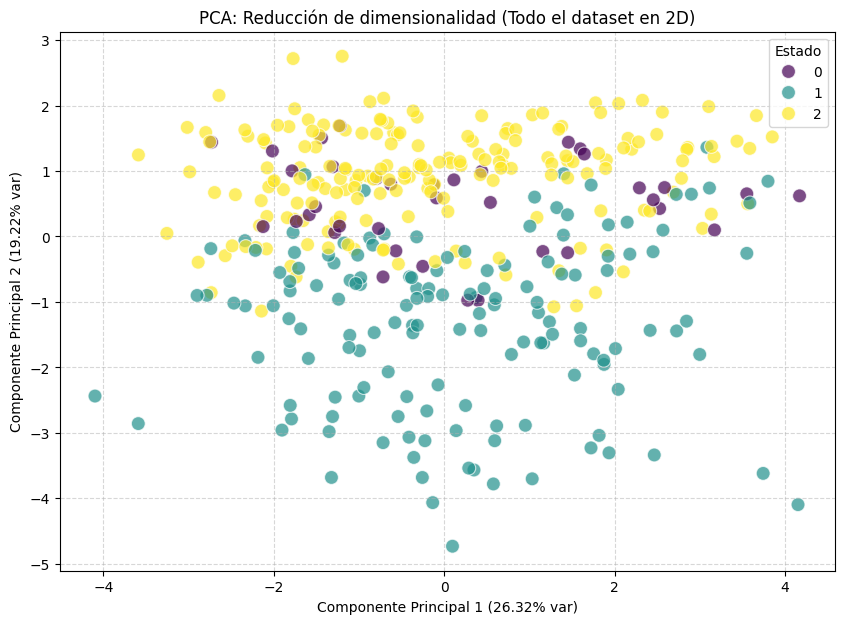

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Heatmap ---
plt.figure(figsize=(12, 10))
# Calculamos la matriz de correlación
correlation_matrix = df.corr()
# Pintamos
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de Correlaciones")
plt.show()

# --- PCA ---
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Group'] = y

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Group',       
    palette='viridis', 
    data=pca_df,
    s=100,             
    alpha=0.7         
)

plt.title("PCA: Reducción de dimensionalidad (Todo el dataset en 2D)")
plt.xlabel(f"Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.legend(title='Estado')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---
* **Ejercicio 3**

Primero de todo, como la salida de la MLP son 3 neuronas, los distintos casos que puede tener la variable 'Group', es necesario relizar OneHot Encoding para 'y'. 

In [166]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder 
import numpy as np 
from mlp import MLP 
# Preparamos y dividimos los datos en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

encoder = OneHotEncoder(sparse_output=False)

y_train_oh = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_oh = encoder.transform(y_test.reshape(-1, 1))

Ahora calculamos las neuronas de entrada, de salida y definimos las de las capas ocultas. Inicializamos el MLP y empezamos el aprendizaje. 

Primero se va a probar con una capa oculta de 32 neuronas y luego con 2 capas ocultas de 32 y 16

In [167]:
HIDDEN_LAYERS = [32,32] # Primero solo 32 luego 32 y 16
ITERATIONS_COMPARE = 12000
LEARNING_RATE_COMPARE = 0.1
REGULARIZATION_COMPARE = 0.0001
SEED = 42
EPSILOM_INIT = 0.12

mlp = MLP(X_train.shape[1], HIDDEN_LAYERS,  y_train_oh.shape[1], SEED, EPSILOM_INIT)
costs = mlp.backpropagation(
        X_train, y_train_oh, 
        alpha=LEARNING_RATE_COMPARE, 
        lambda_=REGULARIZATION_COMPARE, 
        numIte=ITERATIONS_COMPARE, 
        verbose=100
    )

As, _ = mlp.feedforward(X_test)
y_pred = mlp.predict(As[-1])
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc*100:.2f}%")

from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f"Matriz de confusion - Accuracy: {acc*100:.2f}% - Hidden Layers: {HIDDEN_LAYERS}")
plt.show()


Iteration      1: Cost   2.2877   
Iteration    101: Cost   1.6507   
Iteration    201: Cost   1.6478   
Iteration    301: Cost   1.6410   
Iteration    401: Cost   1.6203   
Iteration    501: Cost   1.5324   
Iteration    601: Cost   1.1581   
Iteration    701: Cost   0.7500   
Iteration    801: Cost   0.6079   
Iteration    901: Cost   0.5614   
Iteration   1001: Cost   0.5422   
Iteration   1101: Cost   0.5323   
Iteration   1201: Cost   0.5261   
Iteration   1301: Cost   0.5217   
Iteration   1401: Cost   0.5180   
Iteration   1501: Cost   0.5145   
Iteration   1601: Cost   0.5110   
Iteration   1701: Cost   0.5072   
Iteration   1801: Cost   0.5030   
Iteration   1901: Cost   0.4982   
Iteration   2001: Cost   0.4926   
Iteration   2101: Cost   0.4863   
Iteration   2201: Cost   0.4792   
Iteration   2301: Cost   0.4712   
Iteration   2401: Cost   0.4627   
Iteration   2501: Cost   0.4537   
Iteration   2601: Cost   0.4446   
Iteration   2701: Cost   0.4357   
Iteration   2801: Co

KeyboardInterrupt: 

---
* **Ejercicio 4**


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Se va cambiando max_depth para lograr un buen ajuste
tree_clf = DecisionTreeClassifier(random_state=42, max_depth=8)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f"Accuracy Decision Tree: {acc_tree*100:.2f}%")

cm_tree = confusion_matrix(y_test, y_pred_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree)

plt.figure(figsize=(8, 8))
disp.plot(cmap=plt.cm.Greens, values_format='d') # Uso verde para distinguirlo de tu MLP
plt.title("Matriz de Confusión - Decision Tree")
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(tree_clf, filled=True, feature_names=df.columns[:-1], class_names=['Converted', 'Demented', 'Nondemented'], fontsize=10)
plt.title("Árbol de Decisión Generado")
plt.show()

---
* **Ejercicio 5** 

Puesto que ambas tienen una precision parecida, no habria mucha diferencia entre la prediccion de una u otra. Sin embargo, en el proceso del arbol de precision se pueden observar los patrones por los que esta decidiendo. Por lo que, para poderlos interpretar de forma humana, es mas sencillo. Esto pasa puesto que se trata de un caso médico en donde es importante saber la sucesion lógica que se ha seguido para llegar a la conclusion de padecer demencia o no. 


---
* **Ejercicio 6** 

Sustituimos Converted por Demented. Para ello, recuperamos los nombres que teniamos. Sustituimos Converted por Demented y asignamos manualmente los valores 0 o 1 en funcion de Demented o Nondemented. 

Iteration      1: Cost   0.7260   
Iteration    101: Cost   0.6922   
Iteration    201: Cost   0.6911   
Iteration    301: Cost   0.6896   
Iteration    401: Cost   0.6869   
Iteration    501: Cost   0.6815   
Iteration    601: Cost   0.6695   
Iteration    701: Cost   0.6385   
Iteration    801: Cost   0.5564   
Iteration    901: Cost   0.4115   
Iteration   1001: Cost   0.2932   
Iteration   1101: Cost   0.2298   
Iteration   1201: Cost   0.1986   
Iteration   1301: Cost   0.1828   
Iteration   1401: Cost   0.1739   
Iteration   1501: Cost   0.1686   
Iteration   1601: Cost   0.1652   
Iteration   1701: Cost   0.1629   
Iteration   1801: Cost   0.1613   
Iteration   1901: Cost   0.1601   
Iteration   2001: Cost   0.1592   
Iteration   2101: Cost   0.1585   
Iteration   2201: Cost   0.1580   
Iteration   2301: Cost   0.1575   
Iteration   2401: Cost   0.1571   
Iteration   2501: Cost   0.1568   
Iteration   2601: Cost   0.1565   
Iteration   2701: Cost   0.1562   
Iteration   2801: Co

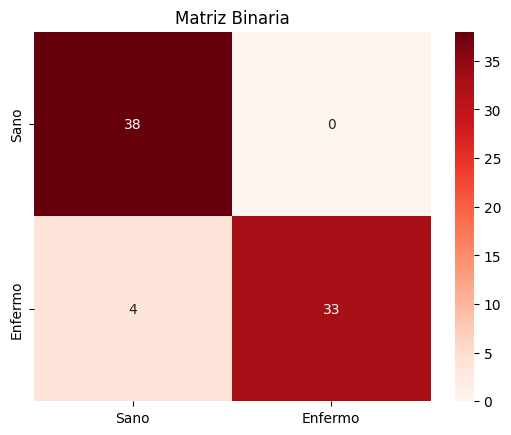

In [172]:
nombres = le.inverse_transform(y)

rules = {
    'Demented': 1,    
    'Converted': 1,   
    'Nondemented': 0 
}
y_bin = pd.Series(nombres).map(rules).values

# ¡OJO! ESTO SÍ QUE TE LO TIENES QUE APRENDER)
# La red de 1 neurona necesita columnas verticales
y_bin = y_bin.reshape(-1, 1)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_scaled, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

n_features = X_train_b.shape[1]
n_outputs = 1  # Una sola neurona de salida para clasificación binaria

mlp_bin = MLP(n_features, HIDDEN_LAYERS, n_outputs, SEED, EPSILOM_INIT)

costs_bin = mlp_bin.backpropagation(
    X_train_b, y_train_b,
    alpha=LEARNING_RATE_COMPARE,
    lambda_=REGULARIZATION_COMPARE,
    numIte=ITERATIONS_COMPARE,
    verbose=100
)

As_bin, _ = mlp_bin.feedforward(X_test_b)
# No se usa predic porque esto lo evalua por que columna de salida es mejor. 
# En binario, solo hay una columna, por lo que el umbral se hace manualmente.
y_pred_bin = mlp.predict(As_bin[-1])
# Como es binario, aplicamos un umbral de 0.5
y_pred_bin = (As_bin[-1] >= 0.5).astype(int)
acc = accuracy_score(y_test_b, y_pred_bin)
print(f"Accuracy Binario: {acc*100:.2f}%")
cm = confusion_matrix(y_test_b, y_pred_bin)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Sano', 'Enfermo'], yticklabels=['Sano', 'Enfermo'])
plt.title("Matriz Binaria")
plt.show()